<a href="https://colab.research.google.com/github/AllenInstitute/EducationAndEngagement/blob/main/NeuroCodingWorkshop/06_PatchSeq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Defining cell types by their molecular features

So far, we compared and contrasted **electrophysiology features**, and **structure** of different cell types in the brain. **Gene expression patterns** are also commonly used to define neuronal cell types. Since at any moment each cell makes mRNA from only a fraction of the genes it carries, by measuring the cell's RNA transcripts we can get a sense of the cell's gene expression patterns. The sum of a cell's RNA transcripts is called its **transcriptome**, and single-cell RNA sequencing (**scRNA-seq**) is one commonly used transcriptomic technology.

Here is a list of scRNA-seq data published by the Allen Institute for Brain Science:
- Adult mouse cortical cell taxonomy revealed by single cell transcriptomics (Tasic et al. 2016)

- Shared and distinct transcriptomic cell types across neocortical areas (Tasic et al. 2018)

- A taxonomy of transcriptomic cell types across the isocortex and hippocampal formation (Yao et al. 2021)

Sequencing data from scRN-seq experiments are usually contained in a matrix of expression values. This matrix is known as a **count matrix**, which contains the number of reads mapped to each gene (row) in each cell (column).

### What is a 'read'?
In a typical scRNA-Seq experiment, the mRNA molecules are first reverse transcribed into cDNA molecules, which are then amplified and converted into libraries of cDNA fragments. These cDNA libraries are then sequenced, and each sequenced fragment (or read) corresponds to a portion of a cDNA molecule. We can use computer algorithms to align these reads to a reference genome or transcriptome and determine the gene(s) from which each read originates. By counting the number of reads that map to each gene, we can estimate the expression level of individual genes in individual cells.

## Patch-seq
Patch-seq is an experimental technique that combined scRNA-seq with intracellular electrophysiology, which enables one to directly relate the transcriptomic features of a given neuron to other identifying characteristics of the same neuron.
![](https://github.com/nuoxuxu/gene-ephys-tutorial/blob/main/figures/schematic_gene.png?raw=true)

In [1]:
#@title Allen Institute Patch-seq Pipeline Lab Tour {display-mode: "form"}

from IPython.display import HTML

HTML("""
<iframe width="800" height="450"
        src="https://www.youtube.com/embed/-sSOYfnz-6o"
        title="YouTube video player"
        frameborder="0"
        referrerpolicy="strict-origin-when-cross-origin"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture"
        allowfullscreen>
</iframe>
""")

<hr>

## Notebook Objectives
- Obtain normalized count matrix from raw read counts
- Explore the [Patch-seq dataset](https://linkinghub.elsevier.com/retrieve/pii/S009286742031254X) generated from mouse primary visual cortex.
- Correlate  gene expression with intracellular electrophsiological features.

<a name="setup"></a>
# Step 1. Setting up our coding environment


## Importing packages
First, we have several packages we need to run the analyses below. This cell will take a minute or two to run.

>**Task**: While this cell is running, look up whichever packages here are new to you!

In [2]:
# Standard analysis and visualization packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# New packages...
import seaborn as sns
import urllib.request
import json
import umap
import gc
import scipy.sparse as sparse
%whos

Variable         Type       Data/Info
-------------------------------------
HTML             type       <class 'IPython.core.display.HTML'>
PCA              ABCMeta    <class 'sklearn.decomposition._pca.PCA'>
StandardScaler   type       <class 'sklearn.preproces<...>ng._data.StandardScaler'>
gc               module     <module 'gc' (built-in)>
json             module     <module 'json' from '/usr<...>on3.12/json/__init__.py'>
np               module     <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
pd               module     <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
plt              module     <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns              module     <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
sparse           module     <module 'scipy.sparse' fr<...>cipy/sparse/__init__.py'>
umap             module     <module 'umap' from '/usr<...>ckages/umap/__init__.py'>
urllib           module     <module 'urllib' from '/u<...>3.12/url

<a name="patch_seq"></a>
# Step 2. Obtaining count matrix for the Patch-seq dataset

## Download count matrix for the Patch-seq dataset


Run the code cell below to download the count matrix. This step should only take a few seconds.

In [3]:
import os

file_name = 'patchseq_count_matrix.parquet'

if not os.path.exists(file_name):
    !wget "https://github.com/AllenInstitute/EducationAndEngagement/releases/download/patchseq-data-v1/patchseq_count_matrix.parquet"

The count matrix is stored as a [Parquet](https://parquet.apache.org/) file, a compressed binary format for tabular data that is much faster to download and read than a raw csv file. We can read it directly into a Pandas DataFrame object using `pd.read_parquet()`.

In [4]:
count_matrix = pd.read_parquet('patchseq_count_matrix.parquet')
count_matrix.head()

,gene_name,PS0810_E1-50_S88,PS0817_E1-50_S19,PS0817_E1-50_S25,PS0817_E1-50_S26,PS0817_E1-50_S27,PS0817_E1-50_S28,PS0817_E1-50_S46,PS0817_E1-50_S52,PS0830_E1-50_S17,...,SM-J39ZH_S561_E1-50,SM-J39ZH_S562_E1-50,SM-J39ZH_S565_E1-50,SM-J39ZH_S566_E1-50,SM-J39ZH_S571_E1-50,SM-J39ZH_S576_E1-50,SM-J3A1L_S592_E1-50,SM-J3A1L_S593_E1-50,SM-J3A1L_S603_E1-50,SM-J3A1L_S604_E1-50
0,0610005C13Rik,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0610006L08Rik,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0610007P14Rik,0,0,0,81,51,35,0,0,483,...,0,0,14,0,14,0,20,38,4,56
3,0610009B22Rik,0,0,41,0,0,0,0,25,0,...,21,0,12,13,23,38,0,0,0,54
4,0610009E02Rik,0,0,0,0,0,1,11,0,0,...,0,0,9,0,1,0,0,13,0,50


Below, we'll do some cleaning up of the `count_matrix`, and then show it.

**Note**: You can only run the cell below once. (See if you can answer why!)

In [5]:
# Set the index to be the gene name
count_matrix.set_index("gene_name", inplace = True)

# remove genes that are not expressed in any cells
count_matrix = count_matrix.iloc[np.flatnonzero(count_matrix.sum(axis = 1) != 0), :]

# remove genes that are barely detected (present in fewer than 100 of the ~4,400 cells)
# this is a standard scRNA-seq QC step, and it keeps the notebook light enough to run on free Colab
n_detected = (count_matrix > 0).sum(axis = 1)
count_matrix = count_matrix.loc[n_detected >= 100, :]

# use a smaller integer type to cut memory usage in half
# count_matrix = count_matrix.astype('int32')

print(f"There are {count_matrix.shape[1]} cells and {count_matrix.shape[0]} genes in the count matrix:")

# Show the first 5 rows of the count matrix
count_matrix.head()

There are 4435 cells and 25170 genes in the count matrix:


,PS0810_E1-50_S88,PS0817_E1-50_S19,PS0817_E1-50_S25,PS0817_E1-50_S26,PS0817_E1-50_S27,PS0817_E1-50_S28,PS0817_E1-50_S46,PS0817_E1-50_S52,PS0830_E1-50_S17,PS0830_E1-50_S19,...,SM-J39ZH_S561_E1-50,SM-J39ZH_S562_E1-50,SM-J39ZH_S565_E1-50,SM-J39ZH_S566_E1-50,SM-J39ZH_S571_E1-50,SM-J39ZH_S576_E1-50,SM-J3A1L_S592_E1-50,SM-J3A1L_S593_E1-50,SM-J3A1L_S603_E1-50,SM-J3A1L_S604_E1-50
gene_name,,,,,,,,,,,,,,,,,,,,,
0610005C13Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610006L08Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610007P14Rik,0,0,0,81,51,35,0,0,483,89,...,0,0,14,0,14,0,20,38,4,56
0610009B22Rik,0,0,41,0,0,0,0,25,0,64,...,21,0,12,13,23,38,0,0,0,54
0610009E02Rik,0,0,0,0,0,1,11,0,0,0,...,0,0,9,0,1,0,0,13,0,50


In this count matrix, each row represents one gene and the row names are the gene names, e.g., **0610005C13Rik**.

<details>
<summary> <font color='blue'>Click here for explanation why this gene has a name that does not seem to make any sense </font></summary>
You might wonder why this gene has a name that does not seem to make any sense. This is because 0610005C13Rik is an example of a placeholder name that is often given to genes when they are first discovered. This type of name is typically used when the function of the gene is not yet known. Once the function of a gene is better understood, it may be given a more descriptive name that reflects its function.
</details>



On the other hand, each column in the count matrix represents one cell and the column names are `transcriptomic_sample_id`, e.g., `PS0810_E1-50_S88`, which uniquely identify the transcriptomic data collected from each cell.

<a name="normalize"></a>
# Step 3. Normalizing gene counts CPM


Below, we'll import the library size for each cell (more on this later, but for now, we'll get this computationally-intensive step out of the way).

In [6]:
# Import precomputed library sizes for each cell, each row contains the library size for one cell
original_lib_size = pd.read_csv(urllib.request.urlopen("https://raw.githubusercontent.com/nuoxuxu/gene-ephys-tutorial/main/data/lib_size.csv"), sep = "\t", index_col = 0)

# Remove cells that contain NA values
lib_size = original_lib_size.dropna().loc[original_lib_size.library_size != 0]

# Remove the cells that have been removed in the previous step from lib_size
count_matrix = count_matrix.loc[:, count_matrix.columns.isin(lib_size.index)]

print(f"{len(original_lib_size) - len(lib_size)} cells were dropped.")

# Plot a heatmap, similar to the website! Note: this takes a long time
# count_matrix.style.background_gradient(cmap ='RdBu_r')

81 cells were dropped.


The `count_matrix` DataFrame contains raw read counts.

<div class="alert alert-success"><b>Task</b>: Create a histogram below showing the <b>sum</b> of raw read counts detected in individual cells. You can use the sum method (<code>sum()</code>) on your <code>count_matrix</code> dataframe, specifying <code>axis = 0</code> to sum all reads per cell. Set the number of bins to 20 for a bit more resolution on the histogram.</div>

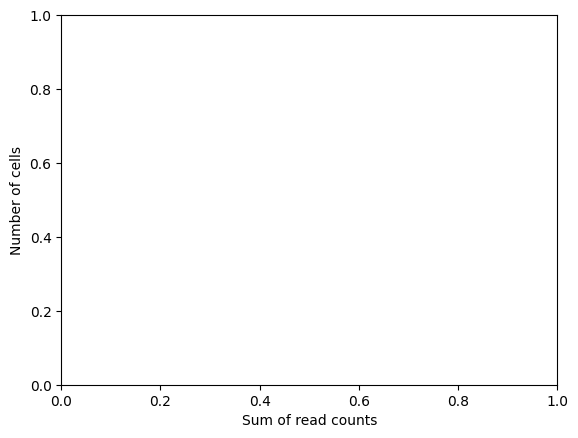

In [7]:
# Add your plotting line below

plt.xlabel("Sum of read counts")
plt.ylabel("Number of cells")
plt.show()

As we can see, there is a wide distribution (notice 1e6 on x axis!), which is largely due to the variability inherent in the experimental technologies used to obtain the read counts, rather than biological variability. Thus, to compare gene expression levels between cells, we need to **normalize** the raw read counts for differences in total number of reads per cells.

One common way to normalize read counts is to calculate **counts per million (CPM)**, which is obtained by dividing read counts for genes by the sum of raw read counts in that cell, also known as **library size**, and multiplying the results by a million, respectively. We imported those values above, and now we can compute the CPM.

### Calculating cpm

<div class="alert alert-success"><b>Task</b>: Calculate counts per million for <code>count_matrix</code>, using precomputed library sizes provided in <code>lib_size</code>.</div>

- Note that `lib_size` is a DataFrame where the index stores the `transcriptomic_sample_id`, and the library size of the corresponding cell is stored in the `library_size` column
- To convert raw read counts for all genes expressed in a cell, we need to divide the raw read counts for each gene by the library size of the cell (which is the total number of reads) and then multiply this number by a factor of 100000.
- Below is an example of how to calculate counts per million for one cell. Your task is to calculate CPM for all cells in `count_matrix`

For the cell whose `transcriptomic_sample_id` is `PS0817_E1-50_S19`, we can extract its `library_size` using the following code:

In [8]:
example_lib_size = lib_size.loc['PS0817_E1-50_S19', 'library_size']
print(f"The library size for cell PS0817_E1-50_S19 is {example_lib_size}.")

The library size for cell PS0817_E1-50_S19 is 692522.0.


The raw read counts of all genes expressed in a cell whose `transcriptomic_sample_id` is `PS0817_E1-50_S19` would be

In [9]:
count_matrix["PS0817_E1-50_S19"]

,PS0817_E1-50_S19
gene_name,
0610005C13Rik,0
0610006L08Rik,0
0610007P14Rik,0
0610009B22Rik,0
0610009E02Rik,0
...,...
Zyx,0
Zzef1,0
Zzz3,60


To calculate the CPM of a gene in a cell, we need to divide the raw read count of all genes expressed in this cell by the library size of this cell, and then multiply the result by a factor of 1000000


In [10]:
count_matrix['PS0817_E1-50_S19'] / lib_size.loc['PS0817_E1-50_S19', 'library_size'] * 1000000

,PS0817_E1-50_S19
gene_name,
0610005C13Rik,0.000000
0610006L08Rik,0.000000
0610007P14Rik,0.000000
0610009B22Rik,0.000000
0610009E02Rik,0.000000
...,...
Zyx,0.000000
Zzef1,0.000000
Zzz3,86.639847


<div class="alert alert-success"><b>Task (continued)</b>: Using a <code>for</code> loop, can you compute the CPM for all cells and assign the result to the corresponding entry in the <code>count_matrix</code>?</div>

**Hint 1**: `count_matrix.columns` returns a list of all `transcriptomic_sample_id`, you can iterate over this list to compute the CPM for each cell

**Hint 2**: use the example for one cell above as a reference.

In [11]:
# First, we need to create an empty list to store the CPM for each cell

# cpm = []

# Then, for each cell, we compute the CPM and append it to the list

# for column in count_matrix.columns:
#     cpm.append(...)

# Finally, we concatenate the list of CPM into a dataframe (Hint: use pd.concat)

# cpm = ...

In [12]:
#@title Click to see solution {display-mode: "form" }
# First, we need to create an empty list to store the CPM for each cell

cpm = []

# Then, for each cell, we compute the CPM and append it to the list

for column in count_matrix.columns:

    this_cpm = count_matrix[column] / lib_size.loc[column, 'library_size'] * 1000000

    cpm.append(this_cpm)

# Finally, we concatenate the list of CPM into a dataframe (Hint: use pd.concat)

cpm = pd.concat(cpm,axis=1)

Below, we'll clean up our workspace by deleting some big variables and slimming down our `cpm`, and then inspect the normalized count matrix `cpm`:

In [13]:
del count_matrix
del lib_size
gc.collect()

# reduce memory usage by downcasting to float32 (no meaningful loss of precision for CPM values)
# cpm = cpm.astype('float32')

# keep genes with values more than 2 in more than 100 cells
n_genes_before = cpm.shape[0]
cpm = cpm.loc[(cpm > 2).sum(axis=1) > 100, :]

print(f"Number of genes before filtering: {n_genes_before}")
print(f"Number of genes after filtering: {cpm.shape[0]}")
cpm.head()

Number of genes before filtering: 25170
Number of genes after filtering: 18199


,PS0810_E1-50_S88,PS0817_E1-50_S19,PS0817_E1-50_S25,PS0817_E1-50_S26,PS0817_E1-50_S27,PS0817_E1-50_S28,PS0817_E1-50_S46,PS0817_E1-50_S52,PS0830_E1-50_S17,PS0830_E1-50_S19,...,SM-J39ZH_S561_E1-50,SM-J39ZH_S562_E1-50,SM-J39ZH_S565_E1-50,SM-J39ZH_S566_E1-50,SM-J39ZH_S571_E1-50,SM-J39ZH_S576_E1-50,SM-J3A1L_S592_E1-50,SM-J3A1L_S593_E1-50,SM-J3A1L_S603_E1-50,SM-J3A1L_S604_E1-50
gene_name,,,,,,,,,,,,,,,,,,,,,
0610007P14Rik,0.0,0.0,0.000000,57.737297,66.848074,23.734993,0.000000,0.00000,210.004017,39.414015,...,0.000000,0.000000,9.554031,0.000000,8.329744,0.000000,17.761674,32.484241,30.061626,34.160589
0610009B22Rik,0.0,0.0,26.496435,0.000000,0.000000,0.000000,0.000000,22.39068,0.000000,28.342663,...,17.660118,0.000000,8.189170,8.710113,13.684579,21.623369,0.000000,0.000000,0.000000,32.940568
0610009E02Rik,0.0,0.0,0.000000,0.000000,0.000000,0.678143,13.582829,0.00000,0.000000,0.000000,...,0.000000,0.000000,6.141877,0.000000,0.594982,0.000000,0.000000,11.113030,0.000000,30.500526
0610009L18Rik,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,1.332642,4.094585,1.340017,0.000000,4.552288,27.530594,0.000000,0.000000,0.610011
0610009O20Rik,0.0,0.0,0.000000,0.000000,0.000000,1.356285,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,3.412154,0.000000,1.189963,0.000000,24.866343,0.000000,0.000000,0.610011


**Transpose** `cpm` so that each row is one cell and each column is one gene.

In [14]:
cpm = cpm.T
cpm.head()

gene_name,0610007P14Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610009O20Rik,0610010F05Rik,0610010K14Rik,0610011F06Rik,0610012G03Rik,0610030E20Rik,...,Zwilch,Zwint,Zxda,Zxdb,Zxdc,Zyg11b,Zyx,Zzef1,Zzz3,l7Rn6
PS0810_E1-50_S88,0.000000,0.000000,0.0,0.0,0.0,5.879061,0.000000,22.340431,19.596869,12.933933,...,0.0,494.233033,0.0,0.0,0.000000,0.000000,0.000000,1.175812,0.000000,0.000000
PS0817_E1-50_S19,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,90.971839,0.000000,...,0.0,2246.860028,0.0,0.0,0.000000,0.000000,0.000000,0.000000,86.639847,2.887995
PS0817_E1-50_S25,0.000000,26.496435,0.0,0.0,0.0,0.646255,0.000000,0.000000,14.217599,0.000000,...,0.0,610.710505,0.0,0.0,0.000000,144.114754,17.448872,0.000000,0.000000,0.000000
PS0817_E1-50_S26,57.737297,0.000000,0.0,0.0,0.0,0.000000,7.840867,9.266480,39.204337,0.712806,...,0.0,343.572556,0.0,0.0,26.373827,22.809796,47.758011,1.425612,39.204337,27.086633
PS0817_E1-50_S27,66.848074,0.000000,0.0,0.0,0.0,10.485972,7.864479,0.000000,0.000000,31.457917,...,0.0,529.541606,0.0,0.0,14.418212,99.616738,28.836424,39.322396,0.000000,14.418212


The normalized read counts are often log-transformed for visualization purposes

In [15]:
cpm = np.log2(cpm + 1)

### Side Note: What does "log scaling" do to our data?

In [16]:
# Generate skewed data
np.random.seed(0)
data = np.random.exponential(scale=1, size=1000)
data_log = np.log(data) # change to log2 if you'd like!

print(data[:10])
print(data_log[:10])

[0.79587451 1.25593076 0.92322315 0.78720115 0.55104849 1.03815929
 0.5755192  2.22352441 3.31491218 0.4836021 ]
[-0.22831376  0.22787694 -0.07988431 -0.23927147 -0.59593247  0.03744924
 -0.55248269  0.79909351  1.19843113 -0.72649282]


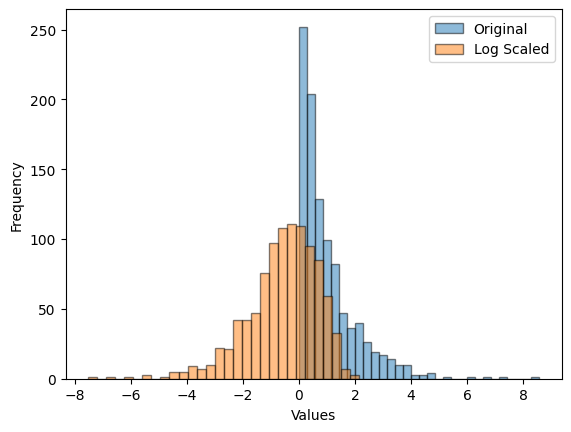

In [17]:
plt.hist(data, bins=30, edgecolor='black',alpha=0.5,label='Original')
plt.hist(data_log, bins=30, edgecolor='black',alpha=0.5,label='Log Scaled')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.legend()
plt.show()

<a name="plot_one_gene"></a>
# Step 4. Plotting expression levels of ion channel genes

Now that we have normalized and log-transformed the raw read counts, we can present the expression levels of selected genes in all cells as a boxplot. The code below creates a boxplot of expression levels of Kv3 voltage-gated potassium channels (Kcnc1, Kcnc2, Kcnc3 and Kcnc4). These channels are known to contribute to neurons' ability to generate high-frequency activity.

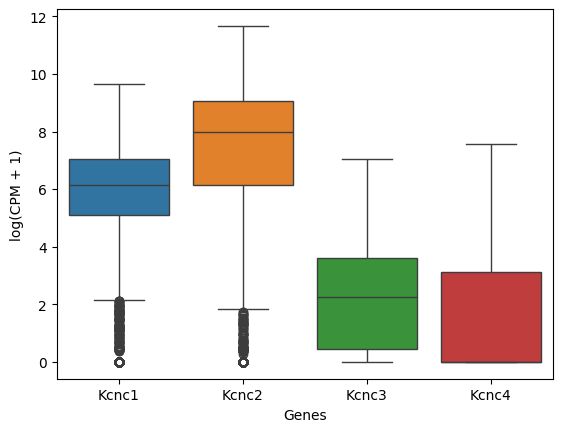

In [18]:
# You can put any genes in this list
gene_list = ["Kcnc1", "Kcnc2", "Kcnc3", "Kcnc4"]

sns.boxplot(cpm[gene_list])

plt.xlabel('Genes')
plt.ylabel('log(CPM + 1)')
plt.show()

However, plotting the expression levels of genes across all cells in the dataset like this is not very helpful. What we want to know is whether the expression level of a gene is different between different neuronal subclasses. Since this dataset contains subclass label for each neuron, we can try to address this question by plotting gene expression across different subclasses.

<a name="labels"></a>
# Step 5. Assigning subclass labels

## Obtaining subclass labels

Since each neuron has already been assigned a subclass label in the paper, our task is to obtain subclass labels (as defined in the original paper) for each cell in `cpm`.

<details>
<summary> <font color='blue'>Click here for explanation how this was done </font></summary>
    
First, we need to convert the `transcriptomics_sample_id` for each column in `cpm` to `cell_specimen_id`. This is because the mapping from each cell to the cell type it is assigned to is stored in a csv file where each row (represents one cell) is identified by  `cell_specimen_id` only.
This step is also necessary for correlating transcriptomic signatures with electrophysiological data, because electrophysiological data are provided in another csv file where `cell_specimen_id` is the only identifier for each cell. After this conversion step we can merge transcriptomic and electrophysiological data based on this shared label:  `cell_specimen_id`.
    
</details>




In [19]:
# Execute this block of code to assign cell subclass labels to all cells

# From the patchseq_metadata file downloaded from the Allen Institute website, we can obtain a mapping from transcriptomics_sample_id to cell_specimen_id
url = "https://raw.githubusercontent.com/nuoxuxu/gene-ephys-tutorial/main/data/20200625_patchseq_metadata_mouse.csv"
metadata = pd.read_csv(urllib.request.urlopen(url), usecols = ["cell_specimen_id",  "transcriptomics_sample_id"])\
    .set_index("transcriptomics_sample_id")\
    .to_dict()["cell_specimen_id"]

# From the SpecimenMetadata file downloaded from the Allen Institute website, we can obtain a mapping from cell_specimen_id to subclass
url = "https://raw.githubusercontent.com/nuoxuxu/gene-ephys-tutorial/main/data/SpecimenMetadata.csv"
ID_to_subclass = pd.read_csv(urllib.request.urlopen(url), usecols=["Specimen ID", "T type sub-class"], index_col=0) \
    ['T type sub-class'].str.replace(' interneuron', '') \
    .to_dict()

In [20]:
# Convert column names from transcriptomics_sample_id to subclass labels
cpm = cpm.assign(subclass = cpm.index.map(metadata).map(ID_to_subclass))

# Subset for cells that belong to the 5 most abundant subclasses
cpm = cpm.loc[cpm.subclass.isin(["Pvalb", "Sst", "Sncg", "Lamp5", "Vip"])]

# Save in case something happens!
cpm.to_csv('cpm.csv')

# Show the first 5 rows of the dataframe
cpm.head()

gene_name,0610007P14Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610009O20Rik,0610010F05Rik,0610010K14Rik,0610011F06Rik,0610012G03Rik,0610030E20Rik,...,Zwint,Zxda,Zxdb,Zxdc,Zyg11b,Zyx,Zzef1,Zzz3,l7Rn6,subclass
PS0810_E1-50_S88,0.000000,0.000000,0.0,0.0,0.0,2.782212,0.000000,4.544759,4.364353,3.800531,...,8.951964,0.0,0.0,0.000000,0.000000,0.000000,1.121554,0.000000,0.000000,Vip
PS0817_E1-50_S19,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,6.523120,0.000000,...,11.134336,0.0,0.0,0.000000,0.000000,0.000000,0.000000,6.453515,1.959026,Sst
PS0817_E1-50_S25,0.000000,4.781173,0.0,0.0,0.0,0.719187,0.000000,0.000000,3.927669,0.000000,...,9.256705,0.0,0.0,0.000000,7.181050,4.205461,0.000000,0.000000,0.000000,Sst
PS0817_E1-50_S26,5.876205,0.000000,0.0,0.0,0.0,0.000000,3.144188,3.359870,5.329279,0.776362,...,8.428664,0.0,0.0,4.774725,4.573483,5.607567,1.278349,5.329279,4.811812,Sst
PS0817_E1-50_S27,6.084236,0.000000,0.0,0.0,0.0,3.521801,3.148036,0.000000,0.000000,5.020499,...,9.051322,0.0,0.0,3.946564,6.652727,4.899003,5.333509,0.000000,3.946564,Sst


## Expression of *Kcnc2* across subclasses

After assigning subclass label to each cell, we can plot the expression levels of genes across subclasses. Since *Kcnc2* is the most abundant gene in this dataset, we will plot the expression level of Kcnc2 across neuronal subclasses.

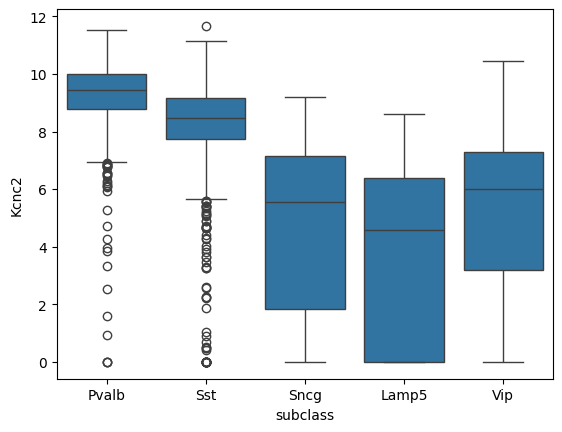

In [21]:
sns.boxplot(cpm[["subclass", "Kcnc2"]], x = "subclass", y = "Kcnc2",
            order = ["Pvalb", "Sst", "Sncg", "Lamp5", "Vip"])
plt.show()

This plot shows that *Kcnc2* expression is higher in the *Pvalb* interneurons, which are known to encompass fast-spiking interneurons.

## Dimensionality reduction and visualization

There are many dimensionality reduction algorithms used to visualize  high-dimensional data on a two-dimensional space, principal components analysis (PCA) is one of them.

In [22]:
#@title Define utility functions {display-mode: "form" }
def select_highly_variable(df, n_top):
    if n_top is None or n_top >= df.shape[1]:
        return df

    # Exclude 'subclass' column if it exists, as it's not a CPM value
    original_subclass = None
    if 'subclass' in df.columns:
        original_subclass = df['subclass']
        df_numeric = df.drop(columns=['subclass'])
    else:
        df_numeric = df.copy()

    gene_var = df_numeric.var(axis=0)
    top_genes = gene_var.sort_values(ascending=False).index[:n_top]

    # Re-add 'subclass' column if it was originally present
    if original_subclass is not None:
        result_df = df.loc[:, top_genes].copy()
        result_df['subclass'] = original_subclass
        return result_df
    else:
        return df.loc[:, top_genes]

def run_pca(df, n_components=2):
    original_subclass = None
    if 'subclass' in df.columns:
        original_subclass = df['subclass']
        df_numeric = df.drop(columns=['subclass'])
    else:
        df_numeric = df.copy()

    scaled = StandardScaler().fit_transform(df_numeric.values)
    pca = PCA(n_components=n_components, random_state=0)
    coords = pca.fit_transform(scaled)
    var_ratio = pca.explained_variance_ratio_

    if original_subclass is not None:
        coords_df = pd.DataFrame(coords, index=df.index)
        coords_df['subclass'] = original_subclass
        return coords_df, var_ratio
    else:
        return coords, var_ratio

In [23]:
# It is common to select for the top 2000 variable genes before running dimensionality reduction
cpm_hvg = select_highly_variable(cpm, 2000)

# Run PCA
pca_coords_df, pca_var_ratio = run_pca(cpm_hvg)

As you can see, the cells that belong to the same subclass should be close to each other in the two-dimensional PC space.

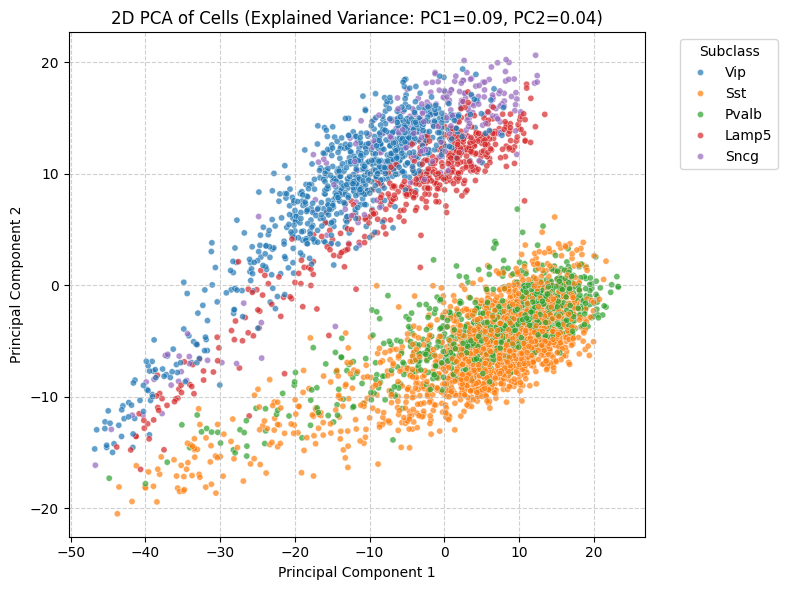

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_coords_df,
    x=0, # First principal component
    y=1, # Second principal component
    hue='subclass', # Color by subclass
    s=20, # Marker size
    alpha=0.7 # Transparency
)
plt.title(f'2D PCA of Cells (Explained Variance: PC1={pca_var_ratio[0]:.2f}, PC2={pca_var_ratio[1]:.2f})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Subclass', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The PCA representation is the result a linear map of the data from its ambient dimension, to low dimension (in the case above 2D). While such projections are useful, there are non-linear methods that can capture non-linear geometry in the data, such as UMAP and t-SNE

<a name="ephys_subclass"></a>
# Step 6. Plotting electrophysiological features across subclass

## Importing extracted electrophysiological features

How do we know that *Pvalb* neurons are fast-spiking? We can import electrophysiological data from the `SpecimenMetadata` file

In [25]:
# You can import any ephys features that are contained in SpecimenMetadata
column_list = ['Specimen ID', 'Avg ISI', 'Fast trough V (long square) (millivolts)', 'Trough V (long square) (millivolts)', 'Peak V (long square) (millivolts)', 'Peak V (short square) (millivolts)',\
                   'Upstroke/downstroke ratio (long square)', 'Threshold V (long square) (millivolts)', 'F I curve slope', 'sag', 'tau', 'Vrest (millivolts)']

# import the ephys features from SpecimenMetadata, only using the columns in column_list
ephys_data = pd.read_csv(
    urllib.request.urlopen("https://raw.githubusercontent.com/nuoxuxu/gene-ephys-tutorial/main/data/SpecimenMetadata.csv"),
    usecols=column_list, index_col=0)

# Assigning the subclass label to each cell
ephys_data["subclass"] = ephys_data.index.map(ID_to_subclass)

# Subset for cells that belong to the 5 most abundant subclasses
ephys_data = ephys_data.loc[ephys_data["subclass"].isin(["Pvalb", "Sst", "Sncg", "Lamp5", "Vip"])]

ephys_data.head()

,Avg ISI,Fast trough V (long square) (millivolts),F I curve slope,Peak V (long square) (millivolts),Peak V (short square) (millivolts),sag,tau,Threshold V (long square) (millivolts),Trough V (long square) (millivolts),Upstroke/downstroke ratio (long square),Vrest (millivolts),subclass
Specimen ID,,,,,,,,,,,,
888317699,77.337143,-49.899998,0.219149,33.968750,34.806252,0.088104,15.476233,-30.881252,-50.025002,1.593478,-68.242925,Sst
765853817,22.306667,-48.737499,0.700000,14.006250,14.231251,0.053379,41.795072,-28.781252,-48.806252,1.496194,-70.211269,Pvalb
671876425,87.811111,-52.343754,0.128299,15.562501,15.081251,0.010278,7.969012,-39.093750,-56.500004,3.799292,-82.387016,Lamp5
906699622,44.145000,-52.568752,0.075000,28.318752,28.806252,0.020501,22.566332,-32.887505,-52.618748,1.849121,-69.601582,Sst
778301240,9.276981,-49.618752,1.802804,27.556252,30.518749,0.086389,12.057492,-29.000002,-49.799999,1.530240,-49.922277,Pvalb


## Plotting electrophysiological features across subclass

We can plot the values of any electrophysiological properties across the five subclass. *F I curve* is the slope of the curve between firing rate (f) and current injected. It is commonly used for distinguishing fast spiking interneurons. The figure shows that *Pvalb* neurons have higher *F I slope* than the rest.

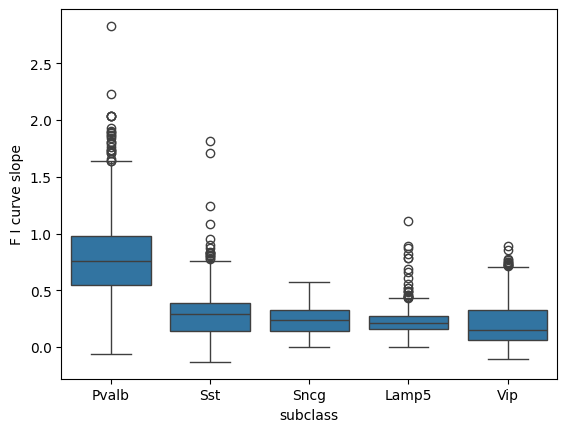

In [26]:
sns.boxplot(ephys_data, x="subclass", y="F I curve slope", order=["Pvalb", "Sst", "Sncg", "Lamp5", "Vip"])
plt.show()

<a name="gene_ephys_corr"></a>
# Step 7. Correlating an electrophysiological feature with the expression of a gene

We have shown that *Kcnc2* is more abundant in Pvalb neurons and that Pvalb neurons have higher values of F I curve slope than other neuronal subclasses.
looked at how gene expression levels and electrophysiological features could vary across neuronal subclasses, respectively. These two observations suggest that expression level of *Kcnc2* could be directly correlated with F I curve slope.

The unique advantage of Patch-seq is that we have both transcriptomic and electrophysiological data for the same cells, which allows us to directly correlate the two.


## Plotting gene expression against electrophysiological feature
Here we are plotting the expression level of *Kcnc2* against F I curve slope, colored by subclass. You can substitute the electrophysiological features and genes with any entries in `cpm` and `ephys_data`.

In [27]:
F_I_slope = ephys_data[["F I curve slope", "subclass"]]

Kcnc2 = cpm["Kcnc2"]
Kcnc2.index = Kcnc2.index.map(metadata)

df = pd.merge(Kcnc2, F_I_slope, how = "inner", left_index = True, right_index = True)

# Save to csv in case something happens!
df.to_csv('merged_Kcnc2_F_I_slope_df.csv')

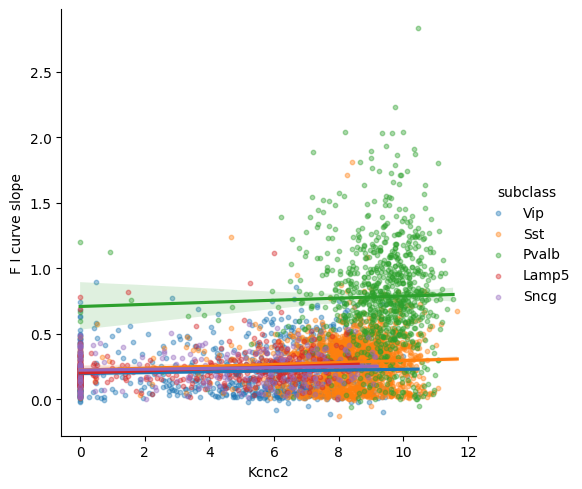

In [28]:
sns.lmplot(df, x = "Kcnc2", y = "F I curve slope", hue = "subclass", scatter_kws = {"s":10, "alpha":0.4})
plt.show()

Because of technical variability in scRNA-seq data, we need to pool raw read counts from cells that belong to the same transcriptomic type (one neuronal subclass contains multiple transcriptomic types), and then normalize and transform the pooled read counts. As a result of this operation, we will have one expression value for each gene for one transcriptomic type. Then we will correlated this "pooled" expression value with the median electrophysiological values of cells within the corresponding transcriptomic type.

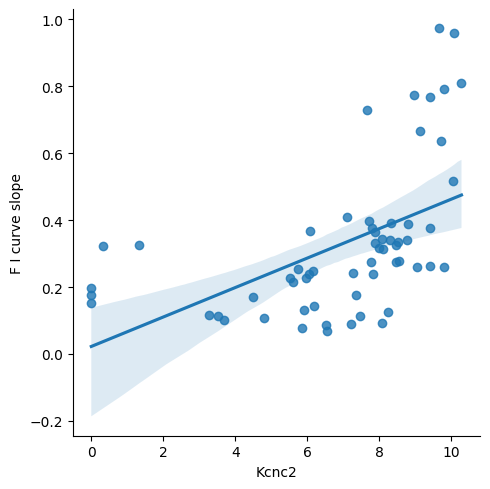

In [29]:
# Obtain mapping from transcriptomic_specimen_ID to T type
ID_to_ttype = pd.read_csv(urllib.request.urlopen(url), usecols=["Specimen ID", "T type"], index_col=0)\
    ['T type']\
    .to_dict()

# Get median F I curve slop values for each T type
median_F_I_slope = ephys_data.assign(ttype = ephys_data.index.map(ID_to_ttype)).groupby("ttype")["F I curve slope"].median()

# Get median expression values of Kcnc2 for each T type
median_Kcnc2 = cpm.assign(ttype = cpm.index.map(metadata).map(ID_to_ttype)).groupby("ttype")["Kcnc2"].median()

# Concatenate `median_F_I_slope` and `median_Kcnc2` into a Pandas DataFrame for plotting in Seaborn
Kcnc2_F_I_slope = pd.concat([median_Kcnc2, median_F_I_slope], axis = 1)

sns.lmplot(Kcnc2_F_I_slope, x = "Kcnc2", y = "F I curve slope")
plt.show()

This plot shows that there is a positive correlation between T type-specific expression of *Kcnc2* and *F I curve slope*.

<a name="corr_matrix"></a>
# Step 8. Constructing Gene-ephys Correlation Matrix

In the *Kcnc2* example we looked at how the expression of one gene could be correlated to one electrophysiological feature. We can compute correlations between all ion channel genes and all electrophysiological features in the dataset.

## Subsetting for genes that code for voltage-gated ion channels
Below, the `IC_list` file contains a dictionary of genes that encode for ion channels.

In [30]:
# Download the list of voltage-gated ion channel genes (VGICs)
IC_list = json.load(urllib.request.urlopen("https://raw.githubusercontent.com/nuoxuxu/gene-ephys-tutorial/main/data/IC_list.json"))

# Keep ion channel genes that are in `cpm`
IC_to_keep = list(set(IC_list['VGIC']).intersection(set(cpm.columns)))

To construct a matrix where each entry is the Pearson's correlation coefficient between one electrophysiological property and expression level of one gene, we need to make sure that exactly the same cells are present in both DataFrames and that they are in the same order.

In [41]:
cpm_ttype = cpm.assign(ttype = cpm.index.map(metadata).map(ID_to_ttype)).drop(columns = "subclass").groupby("ttype").median()[IC_to_keep]

In [43]:
ephys_data_ttype = ephys_data.assign(ttype = ephys_data.index.map(ID_to_ttype)).drop(columns = "subclass").groupby("ttype").median()

Calculating the correlation matrix between the expression of ion channel genes and electrophysiology features


In [44]:
corr_matrix = np.corrcoef(
    np.hstack([cpm_ttype.to_numpy(), ephys_data_ttype.to_numpy()]), rowvar=False)\
        [:cpm_ttype.shape[1], -ephys_data_ttype.shape[1]:]

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Plotting the correlation matrix

**Note**: This cell will take some time to generate!

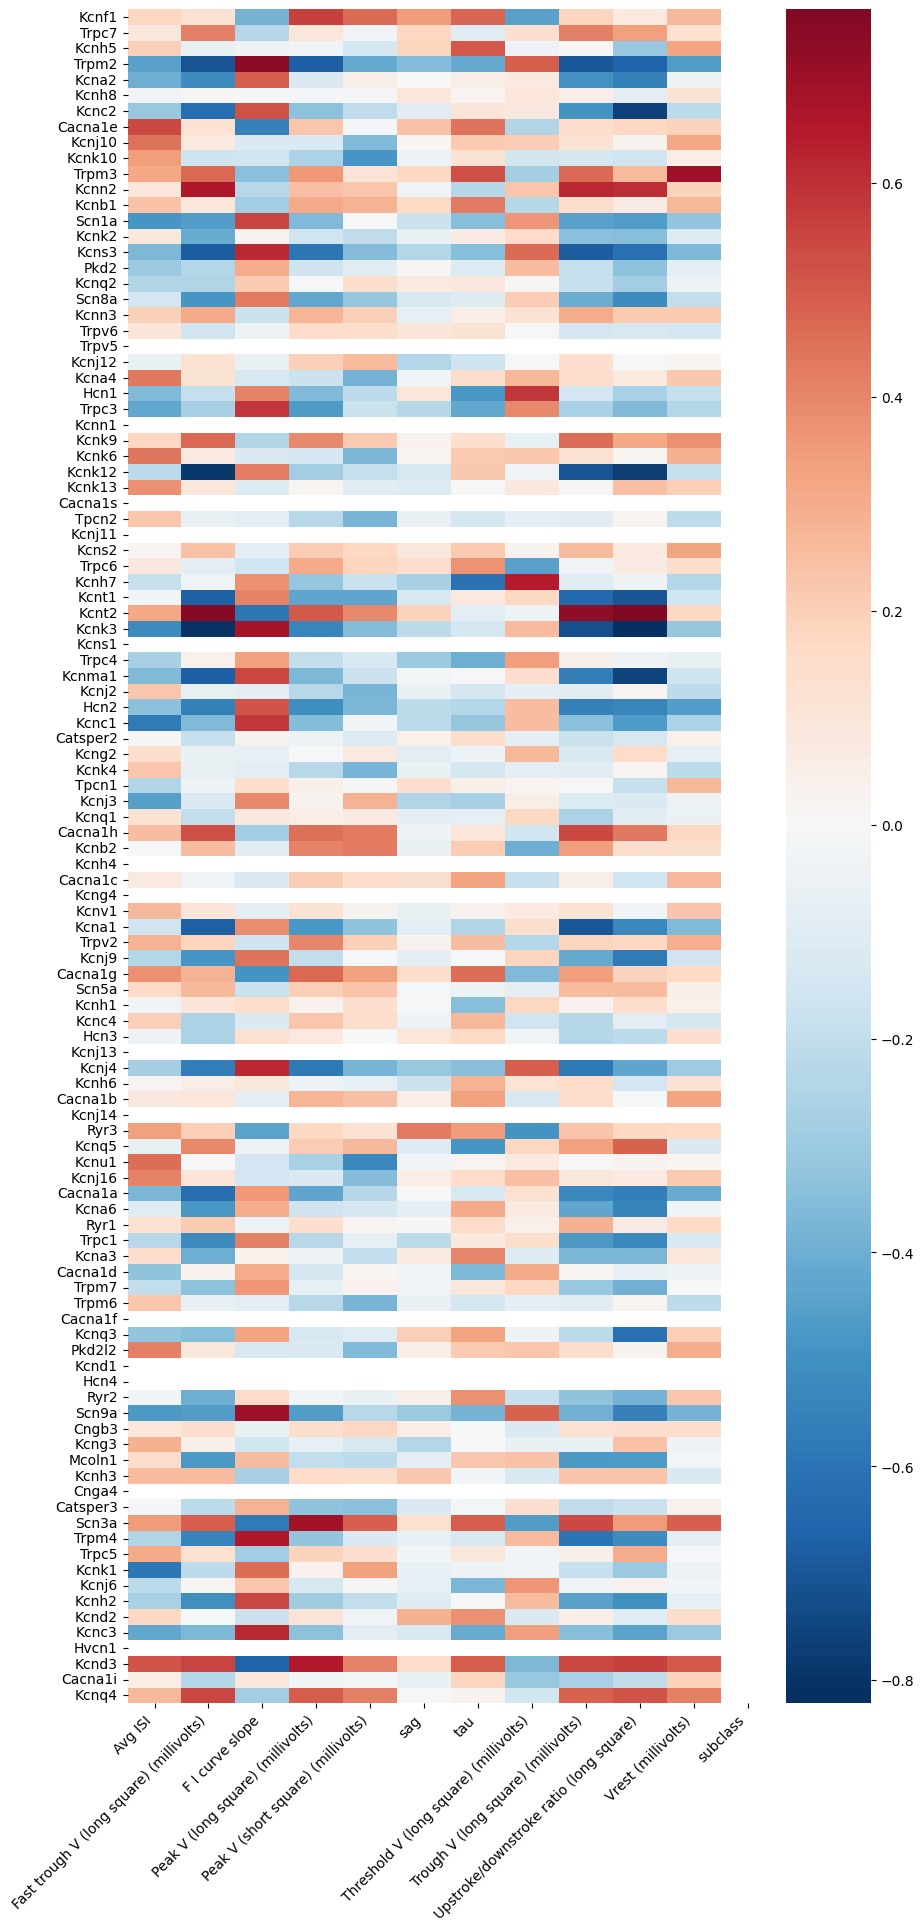

In [45]:
fig, ax = plt.subplots(figsize = (10, 22))
sns.heatmap(
    corr_matrix, cmap = "RdBu_r", center = 0,
    xticklabels = ephys_data.columns,
    yticklabels = cpm_ttype.columns
    )

# rotate the xticklabels
plt.xticks(rotation=45, ha='right')

plt.show()

<details>
<summary> <font color='blue'>In case you do not get the cell above to run, here's what you should see!</font></summary>
    
![image](https://raw.githubusercontent.com/BIPN162/BIPN162_SP24/5663edb04bf133e8a24b37651632f25d0cb68c2f/Data/corrmatrix.png)
    
</details>

<hr>

## About this notebook
This notebook was created by Nuo Xu, a physiology PhD student at the University of Toronto. It was edited for classes at UC San Diego by Ashley Juavinett.